# Keyword Reduction Pipeline (BeauVis-Inspired)

Following the term-reduction methodology from BeauVis (He et al., 2022), we systematically reduce
our ~409 unique keywords to a shortlist of 20–40 candidate terms suitable for a future participant
validation study.

### Pipeline Steps
1. **Load data** — Same source as CommentsPostProcessingFigs notebook
2. **Merge-first consolidation** — Instead of discarding rare keywords (count ≤ 2), use TF-IDF cosine similarity to merge them into their closest higher-count match. Combined with manual synonym groups for known near-duplicates among all keywords.
3. **Criterion-based semantic filtering** — Apply 6 BeauVis-style criteria (relevance, directionality, clarity, cross-VisType applicability, antonym-pair dedup)
4. **Universality scoring** — Composite score = count × number_of_VisTypes
5. **Topic coverage balancing** — Ensure all 7 topics are represented
6. **Final shortlist** — Top 20–40 candidate terms


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from collections import defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

VisTypes = ['Area','Bar','Cont.-ColorPatn','Glyph','Grid','Line','Node-link','Point','Text']

topic_names = [
    'Data Density / Image Clutter',
    'Visual Encoding Clarity',
    'Semantics / Text Legibility',
    'Schema',
    'Color, Symbol, and Texture Details',
    'Aesthetics Uncertainty',
    'Immediacy / Cognitive Load'
]

topic_abbrev = {
    'Data Density / Image Clutter': 'DDIC',
    'Visual Encoding Clarity': 'VEC',
    'Semantics / Text Legibility': 'STL',
    'Schema': 'SCH',
    'Color, Symbol, and Texture Details': 'CSTD',
    'Aesthetics Uncertainty': 'AU',
    'Immediacy / Cognitive Load': 'ICL'
}


## Step 0: Load Data

In [14]:
# Load the same data as CommentsPostProcessingFigs
spreadsheet_id = '1UHdDb-W3M-d29Eubx58XGf9jtnrwcJlP_z8S2U2dJBQ'
sheet_id = '1160817631'
df_keyword_counts = pd.read_csv(
    f'https://docs.google.com/spreadsheets/d/{spreadsheet_id}/export?gid={sheet_id}&format=csv'
)
print(f'Raw records: {len(df_keyword_counts)}')

# Build unique keywords table (same as cell 5 in CommentsPostProcessingFigs)
vt_involvement = (
    df_keyword_counts
    .groupby('keyword')[VisTypes]
    .apply(lambda g: ','.join([vt for vt in VisTypes if (g[vt] > 0).any()]))
    .reset_index()
    .rename(columns={0: 'vistypes_involved'})
)
vt_involvement['n_vistypes'] = vt_involvement['vistypes_involved'].apply(
    lambda x: len(x.split(',')) if x else 0
)

# Use ' | ' as delimiter for topics since "Color, Symbol, and Texture Details" contains commas
TOPIC_SEP = ' | '
topic_involvement = (
    df_keyword_counts
    .groupby('keyword')['topic']
    .apply(lambda g: TOPIC_SEP.join(sorted(g.unique())))
    .reset_index()
    .rename(columns={'topic': 'topics_involved'})
)

kw_counts = (
    df_keyword_counts
    .groupby('keyword', as_index=False)['num_images']
    .sum()
    .rename(columns={'num_images': 'count'})
)

df_all = (kw_counts
    .merge(vt_involvement, on='keyword')
    .merge(topic_involvement, on='keyword')
    .sort_values('count', ascending=False)
    .reset_index(drop=True)
)

print(f'Unique keywords: {len(df_all)}')
df_all.head(10)

Raw records: 500
Unique keywords: 409


,keyword,count,vistypes_involved,n_vistypes,topics_involved
0,color variety/arrangement/distribution,88,"Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-...",9,"Color, Symbol, and Texture Details"
1,more charts/points/lines/shapes/elements,78,"Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-...",9,Data Density / Image Clutter
2,much/more data/info/info spread,58,"Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-...",9,Data Density / Image Clutter
3,easy to interpret/read/understand,52,"Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-...",9,Immediacy / Cognitive Load
4,"domain-specific concepts (e.g., chemical, biol...",46,"Area,Cont.-ColorPatn,Glyph,Grid,Line,Node-link...",8,Schema
5,title/axis/label,34,"Area,Bar,Cont.-ColorPatn,Grid,Line,Node-link,P...",8,Semantics / Text Legibility
6,lack of/not enough axis labels/legend/annotati...,34,"Area,Bar,Cont.-ColorPatn,Glyph,Line,Node-link,...",8,Semantics / Text Legibility
7,more detailed/things,34,"Area,Bar,Cont.-ColorPatn,Glyph,Grid,Node-link,...",8,Data Density / Image Clutter
8,coloring,34,"Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-...",9,"Color, Symbol, and Texture Details"
9,hard to interpret/read/understand,31,"Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-...",9,Immediacy / Cognitive Load


In [15]:
# Quick overview of keyword count distribution
rare = df_all[df_all['count'] < 3]
survivors = df_all[df_all['count'] >= 3]
print(f'Keywords with count < 3 (rare):  {len(rare)}')
print(f'Keywords with count >= 3:        {len(survivors)}')
print(f'\nCount distribution:')
print(df_all['count'].value_counts().sort_index().head(6).to_string())


Keywords with count < 3 (rare):  275
Keywords with count >= 3:        134

Count distribution:
count
1    222
2     53
3     33
4     21
5     11
6      7


## Step 1: Merge-First Consolidation

Instead of discarding 275 rare keywords (count ≤ 2), we attempt to **merge each rare keyword into
its closest higher-count match** using a combination of:

1. **Manual synonym groups** — Hand-curated groups of near-synonyms across ALL keywords (rare + frequent), expanded from the original Step 2 groups to also include rare variants.
2. **TF-IDF cosine similarity** — For rare keywords not covered by manual groups, compute text similarity against all count≥3 keywords. Auto-merge if cosine similarity ≥ threshold.
3. **Truly unmatched** — Keywords with no good match (below threshold and not in any synonym group) are discarded.

Merging adds the rare keyword's count to the target and unions their VisType/topic coverage.


In [18]:
# ---- Step 1: Unified Merge-First Consolidation ----
# Combines manual synonym groups + TF-IDF similarity matching for rare keywords

MIN_COUNT = 3
SIMILARITY_THRESHOLD = 0.35  # cosine similarity threshold for auto-merging

# Separate rare vs. survivors
df_rare = df_all[df_all['count'] < MIN_COUNT].copy()
df_survivors = df_all[df_all['count'] >= MIN_COUNT].copy()

print(f'Starting: {len(df_all)} keywords total')
print(f'  Rare (count < {MIN_COUNT}): {len(df_rare)}')
print(f'  Survivors (count >= {MIN_COUNT}): {len(df_survivors)}')

# ---- Manual synonym groups (expanded to include rare variants) ----
# Each group: list of keywords that are near-synonyms.
# The keyword with the highest count becomes the representative.
# NOTE: These groups span BOTH rare and frequent keywords.
synonym_groups = [
    # --- Immediacy / Cognitive Load ---
    ['more difficult to interpret/read/understand/differentiate',
     'not interpretable/readable/understandable',
     'hard to interpret/read/understand/differentiate',
     'hard to interpret/read/understand',
     'hard to compare/discern/distinguish',
     'hard to see/tell/visualize',
     'hard to focus/follow',
     'hard to identify/extract/find features',
     'more complicated',
     'more difficult',
     'complicated to process',
     # rare variants:
     'hard to read', 'hard to describe', 'hard to measure/model',
     'hard to read shape', 'hard to distinguish colors',
     'harder to view data point', 'struggled to read',
     'less understandable', 'not easily understood', 'less clear',
     'less intuitive', 'low readability', 'unreadable',
     'nothing clear', 'less simple', 'more intricate'],

    ['easy to interpret/read/understand',
     'easier to interpret/read/understand',
     'easier to process/visualize',
     'simple to interpret/read/understand',
     'easier to see/tell/visualize',
     'easy to focus/follow',
     'easy to understand',
     'intuitive',
     # rare variants:
     'easy to read', 'easy to derive meaning',
     'easy to identify/extract/find features',
     'easier to compare/discern/distinguish',
     'fast readability', 'more interpretable/readable/understandable',
     'more legible', 'description easy to read'],

    ['take longer to interpret',
     'more reading/interpretation/understanding',
     'more effort/reading/detailed analysis',
     'attention/squinting to understand',
     'more to read/analyze/understand',
     # rare variants:
     'more thinking', 'multiple interpretation',
     'provokes thought and understanding',
     'require specialized knowledge',
     'not enough knowledge to tell'],

    # --- Data Density / Image Clutter ---
    ['more charts/points/lines/shapes/elements',
     'multiple features/elements/graphs',
     'many points/lines/shapes/elements',
     'too many details/divisions',
     'many/more data/info',
     'few points/lines/shapes/elements',
     'dense points/lines/shapes/elements',
     'too many points/lines/shapes/elements',
     # rare variants:
     'too more points/lines/shapes/elements',
     'multiple points/lines/shapes/elements',
     'multiple shapes', 'multiple interacting elements',
     'multiple aspects', 'more forms',
     'too many sections', 'too many subjects',
     'too many subplots', 'more pixels'],

    ['much/more data/info/info spread',
     'more detailed/things',
     'too much data/info',
     'fine/layered details',
     # rare variants:
     'large dataset', 'diverse information',
     'more nuance information',
     'simple information', 'no data', 'no detail',
     'less detailed/things', 'no more information',
     'multi-year information', 'many measurements',
     'mixed timeline', 'single variable'],

    ['dense/cluttered data/info',
     'dense/cluttered layout',
     'messy/mixed up/noisy/intermingled elements',
     'overlapping shapes/colors/lines',
     # rare variants:
     'dense/cluttered shape', 'cluttered labels/annotations',
     'concentrated', 'dots scattered', 'scattered',
     'scattered squares', 'less empty space',
     'less negative space', 'negative space',
     'convoluted composition', 'information overload',
     'complex design'],

    # --- Color, Symbol, and Texture Details ---
    ['color variety/arrangement/distribution',
     'too many colors',
     'amount of / too many colors',
     'coloring',
     # rare variants:
     'different colors', 'more colors', 'bold colors',
     'appealing colors', 'intense/too many colors',
     'salient colors', 'similar colors', 'same colors',
     'not simple color-wise', 'very different colors',
     'colored bars/charts', 'colored surface',
     'colorless', 'full color image', 'color represents sounds'],

    ['lack of color contrast / hard to distinguish colors',
     'unclear color meaning',
     'ambiguous/confusing colors',
     'more contrast',
     'high contrast',
     'good color contrast/separation/segmentation',
     'low color contrast/separation/segmentation',
     # rare variants:
     'no color difference', 'color differentiation',
     'separate values by color to show differences',
     'shapes and contrasts'],

    ['color shading',
     'black-to-white/color gradient',
     'color scale/scheme',
     # rare variants:
     'color hues', 'color intensity', 'color saturation',
     'color details', 'color dimension', 'color superposition/layer',
     'blended colors', 'clearer coloring',
     'color keys', 'color represents groups',
     'separate color scales', 'color improves readability',
     'white color on black background', 'black color',
     'blue color', 'green color'],

    ['symbols',
     'texture details',
     # rare variants:
     'striped texture', 'indicating symbols',
     'visually stimulating  texture/colors',
     'icons', 'nodes', 'symbols and shading'],

    # --- Semantics / Text Legibility ---
    ['amount of words/context/numbers',
     'more texts/words',
     'word/text/sentence',
     # rare variants:
     'too many texts/words', 'texts/words', 'text',
     'text ratio', 'code/text', 'context/text/description',
     'too many numbers', 'many numbers', 'more numbers',
     'ambiguous numbers', 'words and numbers',
     'numbers and shapes', 'involves numbers',
     'word frequency', 'word source', 'more text boxes',
     'text on picture', 'text and imagery'],

    ['title/axis/label',
     'more title/axis/label',
     'clear title/axis/label',
     'lack of/not enough axis labels/legend/annotations/context',
     # rare variants:
     'unclear labels', 'different labels',
     'labeled axis', 'axis meaning', 'axis numbers',
     'captions', 'highlighted words',
     'label meaning', 'almost no explanation',
     'axis scales', 'x-axis unlabeled'],

    ['word rotation/small font size',
     'different font/word sizes/structure',
     'unclear writing',
     'readability',
     'easier to read',
     # rare variants:
     'text hard to read', 'font', 'single font',
     'small', 'small and simple',
     'hierarchical text', 'order of words',
     'explanation text', 'detailed inscription',
     'description', 'word misoriented'],

    ['too much legend',
     'legend easy to understand',
     # rare variants:
     'lack of legend', 'vague legend',
     'explanatory legend', 'legend on the top',
     'with legend',
     'no interaction',
     'many legend categories', 'number of legend items'],

    # --- Visual Encoding Clarity ---
    ['curves and shapes',
     'shape variety',
     'shape size variation',
     'element sizes',
     'shapes', 'shapes and lines',
     # rare variants:
     'shape', 'overall shape', 'clear shape',
     'unclear shape', 'shape arrangement', 'shape indicators',
     'shape misunderstanding', 'shape subset representation',
     'shape-color mix', 'shapes varied',
     'similar shapes', 'less organic shapes',
     'less uniform shapes', 'uneven shape',
     'categorized shapes', 'colored shape',
     'similar box sizes', 'mixed size', 'size',
     'size variation', 'size decreasing',
     'more squares than shapes',
     'image size', 'length', 'length variation', 'squares'],

    ['straight lines',
     'curved lines',
     'indistinguishable/unintuitive lines',
     'lines',
     # rare variants:
     'few lines', 'smooth lines', 'intersecting lines',
     'precision of lines', 'line movement',
     'line thickness variation', 'line quantity representation',
     'bars as individual lines', 'horizontal bars',
     'number of vertical lines', 'lines and scales',
     'error bars'],

    ['clearer indication',
     'clear indication',
     'unclear shape meaning',
     'unclear meaning',
     'no clear indication',
     'unclear meaning/confusing',
     # rare variants:
     'indication', 'unclear structure',
     'unclear what data conveys', 'unclear where to look/what to see',
     'unclear relation between words', 'unclear filled bars',
     'lack of meaning', 'different word meaning',
     'code meaning', 'visualization meaning',
     'different clarity',
     'unclear movement', 'confusing connection', 'visual cues'],

    ['2D/3D',
     'organized/structured',
     # rare variants:
     'spatial organization', 'grid layout',
     'image layout', 'disposition',
     'more uniform design', 'misaligned',
     'value and graphic alignment',
     'number of levels', 'number distribution',
     'data intersection', 'data trend',
     'image location', 'image portrayal',
     'value representation',
     'frame with values', 'values in the middle',
     'more axes', 'fewer axes'],

    # --- Schema ---
    ['domain-specific concepts (e.g., chemical, biology, map)',
     'unfamiliar concepts/patterns',
     'a specific technique',
     'a specific technique, e.g., bar, pie, circle',
     'a specific domain',
     'abstract',
     'no context or reference',
     'familiar representation',
     # rare variants:
     'technical encoding', 'network representation',
     'metric representation', 'unknown hidden content',
     'multivariate', 'unique', 'unique data point',
     'nonlinearity', 'nonlinear measurement/metric/axis',
     'recognizable objects', 'graph', 'plots',
     'infomration representation', 'representation',
     'context', 'field information',
     'arbitrary imaging', 'drawing style',
     'graphical information', 'factual information',
     'information nuance expressed'],

    # --- Aesthetics Uncertainty ---
    ['distracting/confusing/unclear',
     'looks random/messy/lack structure',
     'less attractive',
     # rare variants:
     'feeling strange', 'visually overwhelming',
     'visually striking', 'stimulus less visible',
     'nothing visible', 'inconsistent', 'irregular',
     'random-like movement', 'unable to sort',
     'unable to remember', 'uninterpretable ranking',
     'pixeled picture', 'different movement'],

    ['visual clarity/appealing',
     'not intuitive/simple data',
     # rare variants:
     'clear and concise', 'clear connection',
     'clear delineation'],
]

# ---- Build keyword→representative mapping from manual groups ----
all_kws_set = set(df_all['keyword'])
manual_merge_map = {}  # keyword → representative keyword

for group in synonym_groups:
    # Only consider members actually present in the data
    members_in_data = [kw for kw in group if kw in all_kws_set]
    if len(members_in_data) <= 1:
        continue
    # Representative = highest count member
    counts = {kw: df_all.loc[df_all['keyword'] == kw, 'count'].values[0] for kw in members_in_data}
    representative = max(counts, key=counts.get)
    for kw in members_in_data:
        manual_merge_map[kw] = representative

n_manual_rare = sum(1 for kw in df_rare['keyword'] if kw in manual_merge_map and manual_merge_map[kw] != kw)
print(f'\nManual synonym groups: {len(synonym_groups)}')
print(f'Rare keywords matched by manual groups: {n_manual_rare}')

# ---- TF-IDF matching for remaining rare keywords ----
# Rare keywords that are NOT in any manual group go to TF-IDF matching.
# Rare keywords that ARE representatives of a manual group stay as representatives
# (their group members' counts will be merged into them).
rare_group_reps = set()  # rare keywords that are group representatives
for kw in df_rare['keyword']:
    if kw in manual_merge_map and manual_merge_map[kw] == kw:
        # This rare keyword is the representative of its group — keep it
        rare_group_reps.add(kw)

rare_unmatched = [kw for kw in df_rare['keyword']
                  if kw not in manual_merge_map and kw not in rare_group_reps]
survivor_kws = df_survivors['keyword'].tolist()

print(f'Rare keywords needing TF-IDF matching: {len(rare_unmatched)}')

# Preprocess: expand slashes and special chars for better token matching
def preprocess_kw(kw):
    """Expand slashes and clean punctuation for TF-IDF."""
    kw = kw.lower()
    kw = kw.replace('/', ' ')
    kw = kw.replace('-', ' ')
    kw = re.sub(r'[^a-z0-9\s]', ' ', kw)
    return ' '.join(kw.split())

# Build TF-IDF on survivor keywords, transform rare keywords, compute similarity
all_texts = [preprocess_kw(kw) for kw in survivor_kws] + [preprocess_kw(kw) for kw in rare_unmatched]
vectorizer = TfidfVectorizer(analyzer='word', ngram_range=(1, 2), min_df=1)
tfidf_matrix = vectorizer.fit_transform(all_texts)

n_surv = len(survivor_kws)
surv_matrix = tfidf_matrix[:n_surv]
rare_matrix = tfidf_matrix[n_surv:]

sim_matrix = cosine_similarity(rare_matrix, surv_matrix)

# For each rare keyword, find best match among survivors
tfidf_merge_map = {}  # rare_kw → (best_survivor, similarity)
tfidf_unmatched = []

for i, rare_kw in enumerate(rare_unmatched):
    best_idx = sim_matrix[i].argmax()
    best_sim = sim_matrix[i, best_idx]
    best_match = survivor_kws[best_idx]
    if best_sim >= SIMILARITY_THRESHOLD:
        tfidf_merge_map[rare_kw] = (best_match, best_sim)
    else:
        tfidf_unmatched.append((rare_kw, best_match, best_sim))

print(f'TF-IDF auto-merged (sim >= {SIMILARITY_THRESHOLD}): {len(tfidf_merge_map)}')
print(f'Truly unmatched (discarded): {len(tfidf_unmatched)}')

# ---- Combine all merges into unified mapping: keyword → representative ----
merge_map = {}  # keyword → representative (for ALL keywords)

# 1) Manual groups take priority
for kw, rep in manual_merge_map.items():
    if kw != rep:
        merge_map[kw] = rep

# 2) TF-IDF merges for rare keywords not in manual groups
for kw, (target, sim) in tfidf_merge_map.items():
    # Target might itself be mapped by manual groups
    final_target = manual_merge_map.get(target, target)
    merge_map[kw] = final_target

# ---- Apply merges: build consolidated DataFrame ----
# Start from all keywords, determine which are representatives vs merged
all_representatives = set(df_all['keyword']) - set(merge_map.keys())
# Also remove truly unmatched rare keywords
truly_unmatched_kws = set(kw for kw, _, _ in tfidf_unmatched)
all_representatives -= truly_unmatched_kws

df_step1 = df_all[df_all['keyword'].isin(all_representatives)].copy()

# Add merged counts, union vistypes/topics
for _, row in df_all.iterrows():
    kw = row['keyword']
    if kw in merge_map:
        rep = merge_map[kw]
        mask = df_step1['keyword'] == rep
        if mask.any():
            df_step1.loc[mask, 'count'] += row['count']
            # Union vistypes
            existing_vt = set(df_step1.loc[mask, 'vistypes_involved'].values[0].split(','))
            new_vt = set(row['vistypes_involved'].split(',')) if row['vistypes_involved'] else set()
            merged_vt = ','.join(sorted((existing_vt | new_vt) & set(VisTypes)))
            df_step1.loc[mask, 'vistypes_involved'] = merged_vt
            df_step1.loc[mask, 'n_vistypes'] = len(merged_vt.split(',')) if merged_vt else 0
            # Union topics
            existing_topics = set(df_step1.loc[mask, 'topics_involved'].values[0].split(TOPIC_SEP))
            new_topics = set(row['topics_involved'].split(TOPIC_SEP)) if row['topics_involved'] else set()
            merged_topics = TOPIC_SEP.join(sorted((existing_topics | new_topics) & set(topic_names)))
            df_step1.loc[mask, 'topics_involved'] = merged_topics

df_step1 = df_step1.sort_values('count', ascending=False).reset_index(drop=True)

print(f'\n{"=" * 70}')
print(f'Step 1 — Merge-First Consolidation:')
print(f'  Before:  {len(df_all)} keywords')
print(f'  Manual-group merged: {sum(1 for kw in merge_map if kw in manual_merge_map)} keywords')
print(f'  TF-IDF auto-merged:  {len(tfidf_merge_map)} keywords')
print(f'  Truly unmatched (discarded): {len(tfidf_unmatched)} keywords')
print(f'  After:   {len(df_step1)} keywords (consolidated representatives)')
print(f'{"=" * 70}')

Starting: 409 keywords total
  Rare (count < 3): 275
  Survivors (count >= 3): 134

Manual synonym groups: 21
Rare keywords matched by manual groups: 260
Rare keywords needing TF-IDF matching: 14
TF-IDF auto-merged (sim >= 0.35): 4
Truly unmatched (discarded): 10

Step 1 — Merge-First Consolidation:
  Before:  409 keywords
  Manual-group merged: 339 keywords
  TF-IDF auto-merged:  4 keywords
  Truly unmatched (discarded): 10 keywords
  After:   56 keywords (consolidated representatives)


In [19]:
# ---- Show merge details ----
# TF-IDF auto-merges
if tfidf_merge_map:
    print('--- TF-IDF auto-merged keywords ---')
    for kw, (target, sim) in sorted(tfidf_merge_map.items(), key=lambda x: -x[1][1]):
        print(f'  "{kw}" → "{target}" (sim={sim:.3f})')

# Truly unmatched (discarded)
if tfidf_unmatched:
    print(f'\n--- Truly unmatched keywords ({len(tfidf_unmatched)}) ---')
    for kw, best, sim in sorted(tfidf_unmatched, key=lambda x: -x[2]):
        print(f'  "{kw}" (best: "{best}", sim={sim:.3f})')

# Rare group representatives (all-rare groups that survive)
if rare_group_reps:
    print(f'\n--- Rare-only group representatives ({len(rare_group_reps)}) ---')
    for kw in sorted(rare_group_reps):
        members = [m for m in manual_merge_map if manual_merge_map[m] == kw and m != kw]
        print(f'  "{kw}" ← {members}')

--- TF-IDF auto-merged keywords ---
  "no measurement/metric" → "no measurement/metric/axis" (sim=0.848)
  "clustered data/info" → "little data/info" (sim=0.466)
  "regions" → "more regions/space" (sim=0.452)
  "y-axis meaning unclear" → "unclear meaning" (sim=0.404)

--- Truly unmatched keywords (10) ---
  "waterfall-like" (best: "random-like shapes", sim=0.248)
  "no square information" (best: "clear text/scale/information", sim=0.168)
  "mismatched number-circle proportion" (best: "a specific technique, e.g., bar, pie, circle", sim=0.114)
  "precision of aspect" (best: "shape point of interest", sim=0.112)
  "exact feature" (best: "color variety/arrangement/distribution", sim=0.000)
  "exact value" (best: "color variety/arrangement/distribution", sim=0.000)
  "eye-catching description" (best: "color variety/arrangement/distribution", sim=0.000)
  "dates" (best: "color variety/arrangement/distribution", sim=0.000)
  "crop production shown" (best: "color variety/arrangement/distributi

## Step 1b: Criterion-Based Semantic Filtering

Following BeauVis Section 5.1, which applied **6 explicit criteria** to prune 209 → 37 terms before
any expert survey, we apply analogous criteria adapted for **visual complexity** rather than aesthetic pleasure:

| # | BeauVis Criterion | Our Adaptation |
|---|---|---|
| 1 | "Related to aesthetic pleasure, not comprehension" | **Related to visual complexity** — keep terms describing properties that make a vis more/less complex |
| 2 | "Appeared ≥ 2 times in sources" | Handled by Step 1 merge (rare terms merged into survivors rather than discarded) |
| 3 | "Usable in a rating scale with clear connotation" | **Clear directional connotation** — exclude ambiguous terms that don't signal more/less complexity |
| 4 | "Easy to understand" | **Unambiguous wording** — exclude vague/subjective terms that are hard to interpret in a Likert statement |
| 5 | "Clearly applies to a visual representation" | **Applies across VisTypes** — exclude terms specific to one data domain or technique |
| 6 | "No opposite-pair redundancy" | **Remove antonym pairs** — keep only the higher-count version when polar opposites exist |

We apply criteria 1, 3, 4, 5, 6 computationally where possible, and flag borderline cases manually.


In [44]:
# ---- Criterion-based semantic filtering (BeauVis §5.1 adaptation) ----
# Now operates on df_step1 (post-merge consolidation)

# Criterion 5: Apply across VisTypes — remove keywords appearing in only 1 VisType
#   (too technique-specific to be a general complexity descriptor)
single_vt = df_step1[df_step1['n_vistypes'] <= 1]['keyword'].tolist()

# Criterion 3 & 4: Clear directional connotation & unambiguous wording
#   Remove keywords that are purely descriptive (not complexity-oriented) 
#   or too vague to convert into a Likert-scale statement.
#   NOTE: Many former members (e.g., 'coloring', 'shapes') are now merged into groups
#   and won't appear as standalone representatives. Only list current representatives
#   that should still be excluded.
vague_or_nondirectional = [
    '-',                                            # data artifact (empty/missing entry)
]

# Criterion 6: Remove antonym-pair redundancy
#   When polar opposites both survived, keep only the higher-count keyword.
#   NOTE: easy/hard interpret pair is intentionally EXCLUDED from this list —
#   both poles represent distinct ends of the readability dimension and are
#   both needed for a bidirectional complexity scale.
antonym_lower = []
antonym_pairs = [
    ('familiar representation', 'unfamiliar concepts/patterns'),
    ('organized/structured', 'looks random/messy/lack structure'),
    ('high contrast', 'lack of color contrast / hard to distinguish colors'),
    ('good color contrast/separation/segmentation', 'low color contrast/separation/segmentation'),
    ('clearer indication', 'no clear indication'),
]
for pos, neg in antonym_pairs:
    pos_row = df_step1[df_step1['keyword'] == pos]
    neg_row = df_step1[df_step1['keyword'] == neg]
    if len(pos_row) > 0 and len(neg_row) > 0:
        if pos_row.iloc[0]['count'] >= neg_row.iloc[0]['count']:
            antonym_lower.append(neg)
        else:
            antonym_lower.append(pos)

# Combine all exclusions
exclude_crit5 = set(single_vt)
exclude_crit34 = set(vague_or_nondirectional)
exclude_crit6 = set(antonym_lower)
all_excluded = exclude_crit5 | exclude_crit34 | exclude_crit6

df_step1b = df_step1[~df_step1['keyword'].isin(all_excluded)].copy().reset_index(drop=True)

print(f'Step 1b — Criterion-based semantic filtering:')
print(f'  Before: {len(df_step1)} keywords')
print(f'  Criterion 5 (n_vistypes ≤ 1):           removed {len(exclude_crit5)} terms')
print(f'  Criterion 3/4 (vague/non-directional):   removed {len(exclude_crit34 - exclude_crit5)} additional terms')
print(f'  Criterion 6 (antonym lower-count):       removed {len(exclude_crit6 - exclude_crit5 - exclude_crit34)} additional terms')
print(f'  After:  {len(df_step1b)} keywords')

# Show what was removed
if single_vt:
    print(f'\n--- Removed by Criterion 5 (single VisType) ---')
    for kw in sorted(single_vt):
        row = df_step1[df_step1['keyword'] == kw].iloc[0]
        print(f'  "{kw}" (count={row["count"]}, vistypes={row["n_vistypes"]})')
if antonym_lower:
    print(f'\n--- Removed by Criterion 6 (lower-count antonym) ---')
    for kw in sorted(antonym_lower):
        if kw not in exclude_crit5 and kw not in exclude_crit34:
            row = df_step1[df_step1['keyword'] == kw]
            if len(row) > 0:
                print(f'  "{kw}" (count={row.iloc[0]["count"]})')


Step 1b — Criterion-based semantic filtering:
  Before: 56 keywords
  Criterion 5 (n_vistypes ≤ 1):           removed 2 terms
  Criterion 3/4 (vague/non-directional):   removed 1 additional terms
  Criterion 6 (antonym lower-count):       removed 0 additional terms
  After:  53 keywords

--- Removed by Criterion 5 (single VisType) ---
  "random-like shapes" (count=3, vistypes=1)
  "read/analyze many figures/items" (count=4, vistypes=1)


## Step 2: Post-Filter Summary

Synonym merging was already performed in Step 1 as part of the unified merge-first consolidation.
This step simply prepares `df_step2` for downstream compatibility (universality scoring, etc.).


In [45]:
# Step 2 is now a pass-through: synonym merging was done in Step 1.
# synonym_groups is already defined in Step 1.
print(f'Synonym groups defined in Step 1: {len(synonym_groups)}')
print(f'Post-criterion keywords: {len(df_step1b)}')


Synonym groups defined in Step 1: 21
Post-criterion keywords: 53


In [46]:
# ---- df_step2 = df_step1b (merging already done in Step 1) ----
df_step2 = df_step1b.copy()
df_step2 = df_step2.sort_values('count', ascending=False).reset_index(drop=True)

print(f'Step 2 — (pass-through, merging done in Step 1)')
print(f'  Keywords: {len(df_step2)}')
print(f'\nTop 20 by count:')
for i, (_, row) in enumerate(df_step2.head(20).iterrows()):
    print(f'  {i+1:2d}. "{row["keyword"]}" (count={row["count"]}, vt={row["n_vistypes"]})')


Step 2 — (pass-through, merging done in Step 1)
  Keywords: 53

Top 20 by count:
   1. "domain-specific concepts (e.g., chemical, biology, map)" (count=179, vt=9)
   2. "hard to interpret/read/understand" (count=161, vt=9)
   3. "color variety/arrangement/distribution" (count=149, vt=9)
   4. "more charts/points/lines/shapes/elements" (count=129, vt=9)
   5. "much/more data/info/info spread" (count=120, vt=9)
   6. "easy to interpret/read/understand" (count=112, vt=9)
   7. "title/axis/label" (count=96, vt=9)
   8. "shapes and lines" (count=95, vt=9)
   9. "amount of words/context/numbers" (count=80, vt=9)
  10. "unclear meaning/confusing" (count=63, vt=9)
  11. "overlapping shapes/colors/lines" (count=61, vt=9)
  12. "word rotation/small font size" (count=52, vt=8)
  13. "lack of color contrast / hard to distinguish colors" (count=52, vt=8)
  14. "distracting/confusing/unclear" (count=49, vt=9)
  15. "take longer to interpret" (count=43, vt=9)
  16. "color shading" (count=40, vt=8)
  

## Step 3: Universality Scoring

Compute a composite score that rewards both **frequency** (count) and **breadth** (number of VisTypes):

$$\text{universality\_score} = \text{count} \times \text{n\_vistypes}$$

Keywords that appear frequently AND across many VisTypes are the best candidates for a
general-purpose complexity scale.

In [47]:
# ---- Compute universality score ----
df_step3 = df_step2.copy()
df_step3['universality_score'] = df_step3['count'] * df_step3['n_vistypes']
df_step3 = df_step3.sort_values('universality_score', ascending=False).reset_index(drop=True)

# Add primary topic (first listed topic — split on TOPIC_SEP to handle "Color, Symbol, ...")
df_step3['primary_topic'] = df_step3['topics_involved'].apply(
    lambda x: x.split(TOPIC_SEP)[0].strip() if pd.notna(x) and x else 'Unknown'
)

print(f'Step 3 — Universality scoring (count × n_vistypes):')
print(f'  Keywords: {len(df_step3)}')
print(f'\nTop 30 by universality score:')
display_cols = ['keyword', 'count', 'n_vistypes', 'universality_score', 'primary_topic']
print(df_step3[display_cols].head(30).to_string(index=True))

Step 3 — Universality scoring (count × n_vistypes):
  Keywords: 53

Top 30 by universality score:
                                                    keyword  count  n_vistypes  universality_score                       primary_topic
0   domain-specific concepts (e.g., chemical, biology, map)    179           9                1611              Aesthetics Uncertainty
1                         hard to interpret/read/understand    161           9                1449              Aesthetics Uncertainty
2                    color variety/arrangement/distribution    149           9                1341  Color, Symbol, and Texture Details
3                  more charts/points/lines/shapes/elements    129           9                1161  Color, Symbol, and Texture Details
4                           much/more data/info/info spread    120           9                1080        Data Density / Image Clutter
5                         easy to interpret/read/understand    112           9              

## Step 4: Topic Coverage Balancing

A good complexity scale must cover all 7 topics. We select the top keywords by universality score
while ensuring **minimum representation per topic**:
- At least 2 keywords per topic (ensuring all 7 topics appear)
- Fill remaining slots with the next-highest-scoring keywords regardless of topic
- Target total: 20–40 keywords

In [48]:
# ---- Topic-balanced selection ----

TARGET_MIN = 20
TARGET_MAX = 41  # increased from 40: keeps both easy+hard interpret/read/understand poles
MIN_PER_TOPIC = 2

selected = set()
remaining = df_step3.copy()

# Phase 1: Ensure minimum per topic
for topic in topic_names:
    topic_kws = remaining[remaining['primary_topic'] == topic].head(MIN_PER_TOPIC)
    selected.update(topic_kws['keyword'].tolist())

print(f'Phase 1 — Minimum {MIN_PER_TOPIC} per topic: {len(selected)} keywords selected')

# Phase 2: Fill to target with highest universality_score keywords not yet selected
remaining_pool = df_step3[~df_step3['keyword'].isin(selected)]
n_to_fill = max(0, TARGET_MAX - len(selected))
fill_kws = remaining_pool.head(n_to_fill)['keyword'].tolist()
selected.update(fill_kws)

print(f'Phase 2 — Filled to {len(selected)} keywords')

# Build final shortlist DataFrame
df_shortlist = df_step3[df_step3['keyword'].isin(selected)].copy()
df_shortlist = df_shortlist.sort_values('universality_score', ascending=False).reset_index(drop=True)

# Check topic coverage
print(f'\n--- Topic coverage in shortlist ---')
for topic in topic_names:
    abbrev = topic_abbrev[topic]
    n = len(df_shortlist[df_shortlist['primary_topic'] == topic])
    kws = df_shortlist[df_shortlist['primary_topic'] == topic]['keyword'].tolist()
    print(f'  [{abbrev:4s}] {topic:45s} : {n:2d} keywords')
    for kw in kws:
        row = df_shortlist[df_shortlist['keyword'] == kw].iloc[0]
        print(f'          - "{kw}" (count={row["count"]}, vistypes={row["n_vistypes"]}, score={row["universality_score"]})')


Phase 1 — Minimum 2 per topic: 12 keywords selected
Phase 2 — Filled to 41 keywords

--- Topic coverage in shortlist ---
  [DDIC] Data Density / Image Clutter                  :  7 keywords
          - "much/more data/info/info spread" (count=120, vistypes=9, score=1080)
          - "amount of words/context/numbers" (count=80, vistypes=9, score=720)
          - "take longer to interpret" (count=43, vistypes=9, score=387)
          - "2D/3D" (count=38, vistypes=9, score=342)
          - "little data/info" (count=20, vistypes=8, score=160)
          - "more parameters/variables" (count=8, vistypes=4, score=32)
          - "more regions/space" (count=4, vistypes=3, score=12)
  [VEC ] Visual Encoding Clarity                       :  9 keywords
          - "lines" (count=38, vistypes=8, score=304)
          - "scale difference" (count=4, vistypes=4, score=16)
          - "design-data relationship" (count=4, vistypes=4, score=16)
          - "understand/read shapes" (count=4, vistypes=4, sco

## Step 5: Final Shortlist

The final candidate terms for a future Likert-scale validation study.

In [49]:
# ---- Display final shortlist ----
print(f'\n{"=" * 80}')
print(f'FINAL SHORTLIST: {len(df_shortlist)} candidate terms')
print(f'{"=" * 80}\n')

display_cols = ['keyword', 'count', 'n_vistypes', 'universality_score', 'primary_topic', 'vistypes_involved']
df_shortlist[display_cols]


FINAL SHORTLIST: 41 candidate terms



,keyword,count,n_vistypes,universality_score,primary_topic,vistypes_involved
0,"domain-specific concepts (e.g., chemical, biol...",179,9,1611,Aesthetics Uncertainty,"Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-..."
1,hard to interpret/read/understand,161,9,1449,Aesthetics Uncertainty,"Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-..."
2,color variety/arrangement/distribution,149,9,1341,"Color, Symbol, and Texture Details","Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-..."
3,more charts/points/lines/shapes/elements,129,9,1161,"Color, Symbol, and Texture Details","Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-..."
4,much/more data/info/info spread,120,9,1080,Data Density / Image Clutter,"Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-..."
5,easy to interpret/read/understand,112,9,1008,Immediacy / Cognitive Load,"Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-..."
6,title/axis/label,96,9,864,Semantics / Text Legibility,"Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-..."
7,shapes and lines,95,9,855,"Color, Symbol, and Texture Details","Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-..."
8,amount of words/context/numbers,80,9,720,Data Density / Image Clutter,"Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-..."
9,unclear meaning/confusing,63,9,567,"Color, Symbol, and Texture Details","Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-..."


In [50]:
# ---- Save shortlist to CSV ----
fig_dir = os.path.join(os.path.dirname(os.getcwd()), 'notebooks', 'figures')
if not os.path.exists(os.path.join(os.path.dirname(os.getcwd()), 'notebooks')):
    fig_dir = os.path.join(os.getcwd(), 'figures')
os.makedirs(fig_dir, exist_ok=True)

csv_path = os.path.join(fig_dir, 'keyword_shortlist_beauvis_method.csv')
df_shortlist.to_csv(csv_path, index=False)
print(f'Saved shortlist CSV to: {csv_path}')

Saved shortlist CSV to: d:\Coding\Copilot\comment_post_processing\figures\keyword_shortlist_beauvis_method.csv


Saved chart to: d:\Coding\Copilot\comment_post_processing\figures\keyword_shortlist_bar_chart.png


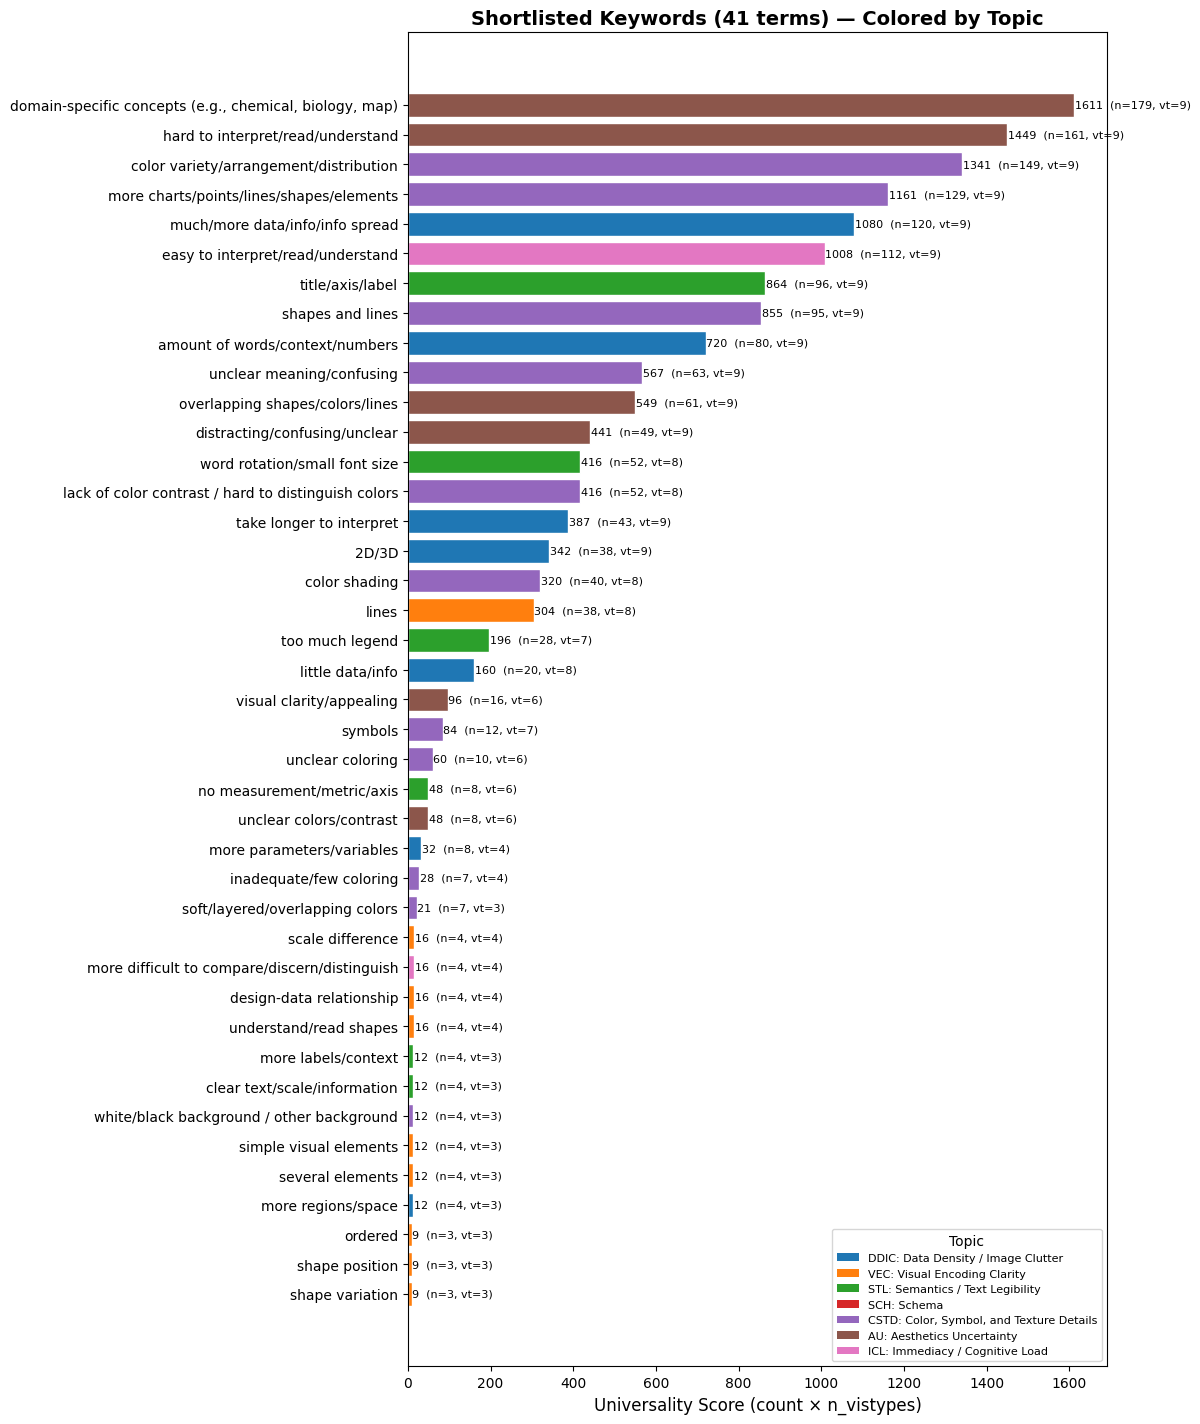

In [51]:
# ---- Visualization: Shortlist bar chart by topic ----

# Color by topic
topic_colors = {
    'Data Density / Image Clutter': '#1f77b4',
    'Visual Encoding Clarity': '#ff7f0e',
    'Semantics / Text Legibility': '#2ca02c',
    'Schema': '#d62728',
    'Color, Symbol, and Texture Details': '#9467bd',
    'Aesthetics Uncertainty': '#8c564b',
    'Immediacy / Cognitive Load': '#e377c2'
}

fig, ax = plt.subplots(figsize=(12, max(6, len(df_shortlist) * 0.35)))

colors = [topic_colors.get(t, 'gray') for t in df_shortlist['primary_topic']]
bars = ax.barh(df_shortlist['keyword'], df_shortlist['universality_score'],
               color=colors, edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('Universality Score (count × n_vistypes)', fontsize=12)
ax.set_title(f'Shortlisted Keywords ({len(df_shortlist)} terms) — Colored by Topic', fontsize=14, fontweight='bold')

# Value labels
for i, (val, kw) in enumerate(zip(df_shortlist['universality_score'], df_shortlist['keyword'])):
    row = df_shortlist.iloc[i]
    ax.text(val + 2, i, f'{val}  (n={row["count"]}, vt={row["n_vistypes"]})',
            va='center', fontsize=8)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=topic_colors[t], label=f'{topic_abbrev[t]}: {t}')
                   for t in topic_names]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8, title='Topic')

plt.tight_layout()

chart_path = os.path.join(fig_dir, 'keyword_shortlist_bar_chart.png')
fig.savefig(chart_path, dpi=150, bbox_inches='tight')
print(f'Saved chart to: {chart_path}')
plt.show()

## Step 6: Reduction Summary

Summary of the full pipeline from 409 → shortlist.

In [52]:
# ---- Pipeline summary ----
print('=' * 70)
print('KEYWORD REDUCTION PIPELINE SUMMARY (Merge-First)')
print('=' * 70)
n_manual_merged = sum(1 for kw in merge_map if kw in manual_merge_map)
n_tfidf_merged = len(tfidf_merge_map)
n_discarded = len(tfidf_unmatched)
print(f'  Step 0  — Raw unique keywords:             {len(df_all):>4d}')
print(f'  Step 1  — After merge-first consolidation:  {len(df_step1):>4d}')
print(f'            (manual-group merged: {n_manual_merged}, TF-IDF merged: {n_tfidf_merged}, discarded: {n_discarded})')
print(f'  Step 1b — After criterion filtering:        {len(df_step1b):>4d}  (−{len(df_step1) - len(df_step1b)})')
print(f'  Step 2  — (pass-through):                   {len(df_step2):>4d}')
print(f'  Step 3  — Scored by universality:           {len(df_step3):>4d}  (same, just scored)')
print(f'  Step 4  — Topic-balanced shortlist:         {len(df_shortlist):>4d}  (target: {TARGET_MIN}–{TARGET_MAX})')
print(f'\n  Overall reduction: {len(df_all)} → {len(df_shortlist)} ({len(df_shortlist)/len(df_all)*100:.1f}% retained)')
print('=' * 70)
print(f'\n  Saved: {csv_path}')
print(f'  Saved: {chart_path}')
print(f'\nNext step: Convert these {len(df_shortlist)} keywords into Likert-scale statements')
print('for a participant validation study (EFA/CFA to reduce to 5–10 final items).')


KEYWORD REDUCTION PIPELINE SUMMARY (Merge-First)
  Step 0  — Raw unique keywords:              409
  Step 1  — After merge-first consolidation:    56
            (manual-group merged: 339, TF-IDF merged: 4, discarded: 10)
  Step 1b — After criterion filtering:          53  (−3)
  Step 2  — (pass-through):                     53
  Step 3  — Scored by universality:             53  (same, just scored)
  Step 4  — Topic-balanced shortlist:           41  (target: 20–41)

  Overall reduction: 409 → 41 (10.0% retained)

  Saved: d:\Coding\Copilot\comment_post_processing\figures\keyword_shortlist_beauvis_method.csv
  Saved: d:\Coding\Copilot\comment_post_processing\figures\keyword_shortlist_bar_chart.png

Next step: Convert these 41 keywords into Likert-scale statements
for a participant validation study (EFA/CFA to reduce to 5–10 final items).


In [53]:
# ---- Build keyword reduction tracking table ----
# For every keyword in df_all, record what happened at each step.

step1_kws = set(df_step1['keyword'])
step1b_kws = set(df_step1b['keyword'])
shortlist_kws = set(df_shortlist['keyword'])
truly_unmatched_kw_set = set(kw for kw, _, _ in tfidf_unmatched)

tracking_rows = []
for _, row in df_all.iterrows():
    kw = row['keyword']
    count = row['count']
    n_vt = row['n_vistypes']
    topics = row['topics_involved']

    if kw in merge_map:
        # This keyword was merged into another
        rep = merge_map[kw]
        source = 'manual group' if kw in manual_merge_map else 'TF-IDF'
        sim_info = ''
        if kw in tfidf_merge_map:
            sim_info = f' (sim={tfidf_merge_map[kw][1]:.3f})'
        tracking_rows.append({
            'keyword': kw, 'count': count, 'n_vistypes': n_vt, 'topics_involved': topics,
            'step1_merge': f'MERGED ({source}){sim_info}',
            'step1b_criteria': '-', 'step4_shortlist': '-',
            'removed_at': f'Step 1: merged into "{rep}"',
            'final_status': 'merged',
            'merged_into': rep
        })
        continue

    if kw in truly_unmatched_kw_set:
        best_match = [b for k, b, s in tfidf_unmatched if k == kw]
        best_sim = [s for k, b, s in tfidf_unmatched if k == kw]
        tracking_rows.append({
            'keyword': kw, 'count': count, 'n_vistypes': n_vt, 'topics_involved': topics,
            'step1_merge': 'DISCARDED',
            'step1b_criteria': '-', 'step4_shortlist': '-',
            'removed_at': f'Step 1: no match (best="{best_match[0]}", sim={best_sim[0]:.3f})',
            'final_status': 'discarded',
            'merged_into': ''
        })
        continue

    if kw not in step1b_kws:
        reason = []
        if kw in exclude_crit5:
            reason.append('Crit5: single VisType')
        if kw in exclude_crit34:
            reason.append('Crit3/4: vague/non-directional')
        if kw in exclude_crit6:
            reason.append('Crit6: antonym lower-count')
        reason_str = '; '.join(reason) if reason else 'criterion filter'
        tracking_rows.append({
            'keyword': kw, 'count': count, 'n_vistypes': n_vt, 'topics_involved': topics,
            'step1_merge': 'kept (rep)',
            'step1b_criteria': 'REMOVED', 'step4_shortlist': '-',
            'removed_at': f'Step 1b: {reason_str}',
            'final_status': 'removed',
            'merged_into': ''
        })
        continue

    if kw not in shortlist_kws:
        tracking_rows.append({
            'keyword': kw, 'count': count, 'n_vistypes': n_vt, 'topics_involved': topics,
            'step1_merge': 'kept (rep)',
            'step1b_criteria': 'kept', 'step4_shortlist': 'NOT SELECTED',
            'removed_at': 'Step 4: below shortlist cutoff',
            'final_status': 'not selected',
            'merged_into': ''
        })
        continue

    # Final shortlist
    tracking_rows.append({
        'keyword': kw, 'count': count, 'n_vistypes': n_vt, 'topics_involved': topics,
        'step1_merge': 'kept (rep)',
        'step1b_criteria': 'kept', 'step4_shortlist': 'SELECTED',
        'removed_at': '',
        'final_status': 'FINAL',
        'merged_into': ''
    })

df_tracking = pd.DataFrame(tracking_rows)
df_tracking = df_tracking.sort_values(['final_status', 'count'], ascending=[True, False]).reset_index(drop=True)

# Save
tracking_path = os.path.join(fig_dir, 'keyword_reduction_tracking.csv')
df_tracking.to_csv(tracking_path, index=False)

# Summary
print('KEYWORD REDUCTION TRACKING TABLE')
print('=' * 70)
status_counts = df_tracking['final_status'].value_counts()
for status in ['FINAL', 'merged', 'not selected', 'removed', 'discarded']:
    n = status_counts.get(status, 0)
    print(f'  {status:<20s}: {n:>4d}')
print(f'  {"TOTAL":<20s}: {len(df_tracking):>4d}')
print(f'\nSaved to: {tracking_path}')

display_cols = ['keyword', 'count', 'n_vistypes', 'final_status', 'removed_at', 'merged_into']
df_tracking[display_cols]


KEYWORD REDUCTION TRACKING TABLE
  FINAL               :   41
  merged              :  343
  not selected        :   12
  removed             :    3
  discarded           :   10
  TOTAL               :  409

Saved to: d:\Coding\Copilot\comment_post_processing\figures\keyword_reduction_tracking.csv


,keyword,count,n_vistypes,final_status,removed_at,merged_into
0,color variety/arrangement/distribution,88,9,FINAL,,
1,more charts/points/lines/shapes/elements,78,9,FINAL,,
2,much/more data/info/info spread,58,9,FINAL,,
3,easy to interpret/read/understand,52,9,FINAL,,
4,"domain-specific concepts (e.g., chemical, biol...",46,8,FINAL,,
...,...,...,...,...,...,...
404,less organized elements,3,3,not selected,Step 4: below shortlist cutoff,
405,little/less text/numbers/context,3,3,not selected,Step 4: below shortlist cutoff,
406,read/analyze many figures/items,4,1,removed,Step 1b: Crit5: single VisType,
407,-,3,3,removed,Step 1b: Crit3/4: vague/non-directional,


## Notes on Methodology Alignment with BeauVis

### BeauVis Reduction Chain (He et al., 2022, §5–6)

| Stage | BeauVis | Count | Our Pipeline | Count |
|---|---|---|---|---|
| 1 | Literature review (176) + expert survey (33 new) | **209** terms | Unique keywords from participant data | **~409** |
| 2 | 6-criteria filtering (§5.1): relevance, frequency ≥2, clear connotation, understandability, applies to vis, no opposite-pair redundancy | **37** terms | Step 1 merge-first (manual synonym groups + TF-IDF) + Step 1b criterion filter | **~80–100** |
| 3 | Expert relevance survey (25 experts, ≥50% agreement) | **31** terms | Pass-through (merging already consolidated) | **~80–100** |
| 4 | Crowd Likert study (989 participants × 15 images × 31 terms) → EFA | **12** items (loading > 0.7 on all 15 images) | Universality scoring + topic-balanced selection | **20–40** |
| 5 | Reliability analysis (Cronbach's α) → best subset | **5 final items** | **Future participant study + EFA/CFA** | **5–10 target** |

### Key Methodological Differences

1. **Merge-first vs. discard:** The original pipeline discarded ~275 rare keywords (count < 3). The new approach merges them into semantically similar higher-count keywords using manual synonym groups and TF-IDF cosine similarity, preserving their count contributions.

2. **Single vs. multi-dimensional construct:** BeauVis measured **one factor** (aesthetic pleasure) → 5 items.
   We have **7 topics** (a multi-dimensional complexity construct) → a final scale of 5–10 items
   would likely include 1–2 items per major dimension.

3. **Term source:** BeauVis drew from literature + expert surveys. Our 409 terms come entirely from
   crowd-sourced participant responses.

4. **Expert review gap:** BeauVis had experts rate each term's relevance (Survey 2, §5.3). We substitute
   computational proxies (TF-IDF matching, universality scoring, topic balancing).

### References
> He, T., Isenberg, P., Dachselt, R., & Isenberg, T. (2022). BeauVis: A Validated Scale for Measuring the Aesthetic Pleasure of Visual Representations. *IEEE TVCG*, 29(1), 363–373.
>
> Cabouat, A.-F., He, T., Isenberg, P., & Isenberg, T. (2024). PREVis: Perceived Readability Evaluation for Visualizations. *IEEE TVCG*.


## Step 7: Map Final Keywords Back to Images

Load the per-image topic sheet (gid `1390591889`), extract original keywords from the 7 topic
columns (stripping sentiment prefixes like `(+)` / `(-)`), match against the final shortlisted
keywords (including synonym-group membership), and add a new column with matched keywords.

In [62]:
# ---- Load per-image topic sheet ----
img_sheet_id = '1390591889'
df_images = pd.read_csv(
    f'https://docs.google.com/spreadsheets/d/{spreadsheet_id}/export?gid={img_sheet_id}&format=csv'
)
print(f'Image sheet: {df_images.shape[0]} rows × {df_images.shape[1]} columns')
print(f'Columns: {list(df_images.columns)}')
df_images.head(3)

Image sheet: 505 rows × 29 columns
Columns: ['ImageName', 'VisType', 'Image', 'NormalizedVC', 'Topics', 'final_keywords', 'Immediacy / Cognitive Load', 'TotalICLItems', 'Data Density / Image Clutter', 'TotalDDCItems', 'Visual Encoding Clarity', 'Semantics / Text Legibility', 'Schema', 'Color, Symbol, and Texture Details', 'Aesthetics Uncertainty', 'Unnamed: 15', 'memorability_score', 'O.KC', 'O.IE', 'O.SE', 'O.FC', 'O.ED', 'O.IG', 'O.H', 'O.CF', 'O.ERGB', 'O.FP', 'O.TiR', 'O.MeC']


,ImageName,VisType,Image,NormalizedVC,Topics,final_keywords,Immediacy / Cognitive Load,TotalICLItems,Data Density / Image Clutter,TotalDDCItems,...,O.SE,O.FC,O.ED,O.IG,O.H,O.CF,O.ERGB,O.FP,O.TiR,O.MeC
0,VisJ.1431.7.png,Line,NaN,0.15,Immediacy / Cognitive Load; Visual Encoding Cl...,unclear meaning/confusing,(-) unclear meaning/confusing,1.0,NaN,0.0,...,1.943,2.852,0.017,0.488,-0.904,74.295,1.305,27,0.00%,1
1,InfoVisJ.2412.7.png,schematic,NaN,0.19,"Color, Symbol, and Texture Details",NaN,NaN,0.0,NaN,0.0,...,2.145,2.634,0.012,0.507,-0.872,116.424,2.912,51,10.13%,2
2,SciVisJ.995.5.png,Bar,NaN,0.22,Immediacy / Cognitive Load; Semantics / Text L...,lack of/not enough axis labels/legend/annotati...,(+) provokes thought and understanding,1.0,NaN,0.0,...,3.078,4.838,0.038,0.717,-0.842,99.534,2.665,110,3.72%,2


Saved: d:\Coding\Copilot\comment_post_processing\figures\normalizedVC_distribution_by_topic.png


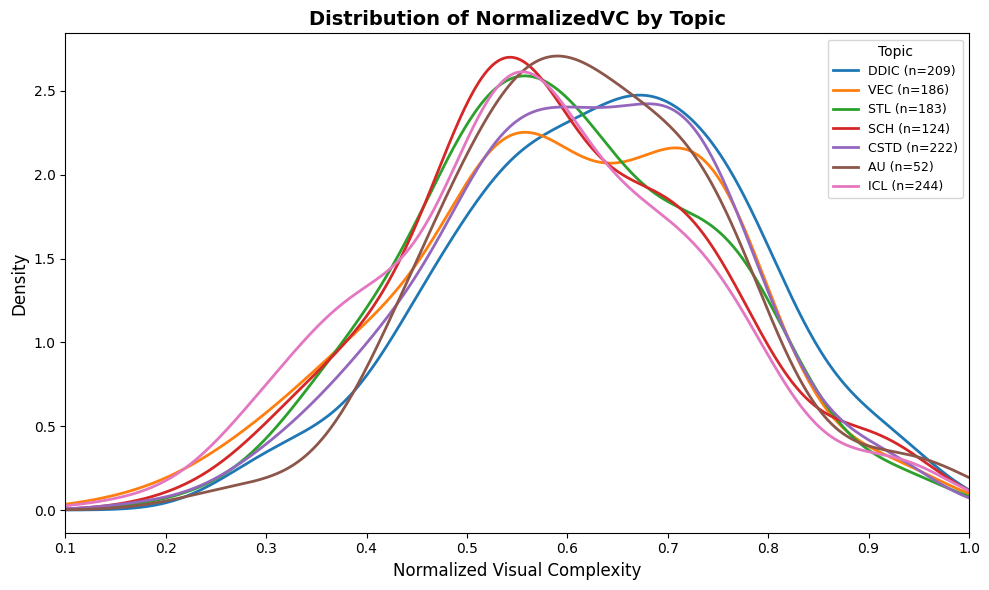

In [63]:
# ---- NormalizedVC distribution by topic (KDE overlay) ----
topic_colors = {
    'Data Density / Image Clutter': '#1f77b4',
    'Visual Encoding Clarity': '#ff7f0e',
    'Semantics / Text Legibility': '#2ca02c',
    'Schema': '#d62728',
    'Color, Symbol, and Texture Details': '#9467bd',
    'Aesthetics Uncertainty': '#8c564b',
    'Immediacy / Cognitive Load': '#e377c2'
}

fig, ax = plt.subplots(figsize=(10, 6))

for topic in topic_names:
    # Images that have at least one keyword in this topic column
    mask = df_images[topic].notna() & (df_images[topic].str.strip() != '')
    scores = df_images.loc[mask, 'NormalizedVC'].dropna()
    if len(scores) > 1:
        scores.plot.kde(ax=ax, label=f'{topic_abbrev[topic]} (n={len(scores)})',
                        color=topic_colors[topic], linewidth=2)

ax.set_xlabel('Normalized Visual Complexity', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Distribution of NormalizedVC by Topic', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, title='Topic')
ax.set_xlim(df_images['NormalizedVC'].min() - 0.05, df_images['NormalizedVC'].max() + 0.05)
plt.tight_layout()

dist_path = os.path.join(fig_dir, 'normalizedVC_distribution_by_topic.png')
fig.savefig(dist_path, dpi=150, bbox_inches='tight')
print(f'Saved: {dist_path}')
plt.show()

Saved: d:\Coding\Copilot\comment_post_processing\figures\normalizedVC_overall_distribution.png

VC stats: min=0.150, max=0.950, mean=0.592, median=0.590, std=0.151
Quartiles: Q1=0.500, Q3=0.700, IQR=0.200


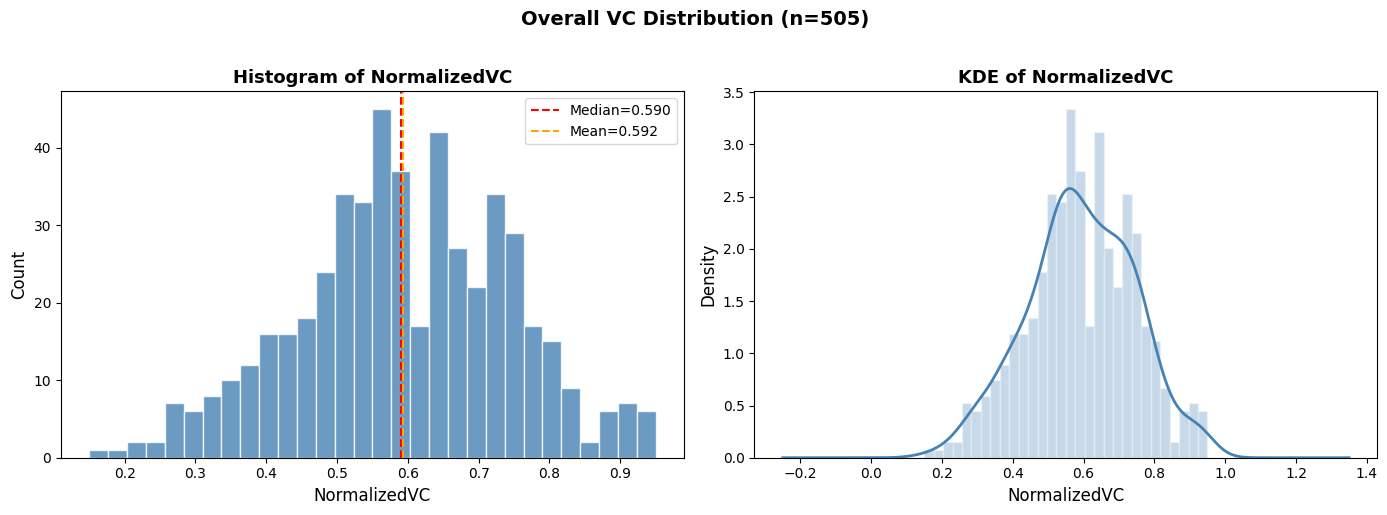

In [64]:
# ---- Overall NormalizedVC distribution ----
vc = df_images['NormalizedVC'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(vc, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(vc.median(), color='red', linestyle='--', linewidth=1.5, label=f'Median={vc.median():.3f}')
axes[0].axvline(vc.mean(), color='orange', linestyle='--', linewidth=1.5, label=f'Mean={vc.mean():.3f}')
axes[0].set_xlabel('NormalizedVC', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Histogram of NormalizedVC', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# KDE with rug
vc.plot.kde(ax=axes[1], color='steelblue', linewidth=2)
axes[1].hist(vc, bins=30, density=True, color='steelblue', edgecolor='white', alpha=0.3)
axes[1].set_xlabel('NormalizedVC', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('KDE of NormalizedVC', fontsize=13, fontweight='bold')

plt.suptitle(f'Overall VC Distribution (n={len(vc)})', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

dist_overall_path = os.path.join(fig_dir, 'normalizedVC_overall_distribution.png')
fig.savefig(dist_overall_path, dpi=150, bbox_inches='tight')
print(f'Saved: {dist_overall_path}')
print(f'\nVC stats: min={vc.min():.3f}, max={vc.max():.3f}, mean={vc.mean():.3f}, median={vc.median():.3f}, std={vc.std():.3f}')
print(f'Quartiles: Q1={vc.quantile(0.25):.3f}, Q3={vc.quantile(0.75):.3f}, IQR={vc.quantile(0.75)-vc.quantile(0.25):.3f}')
plt.show()

Saved: d:\Coding\Copilot\comment_post_processing\figures\topic_proportion_by_vc_bin.png


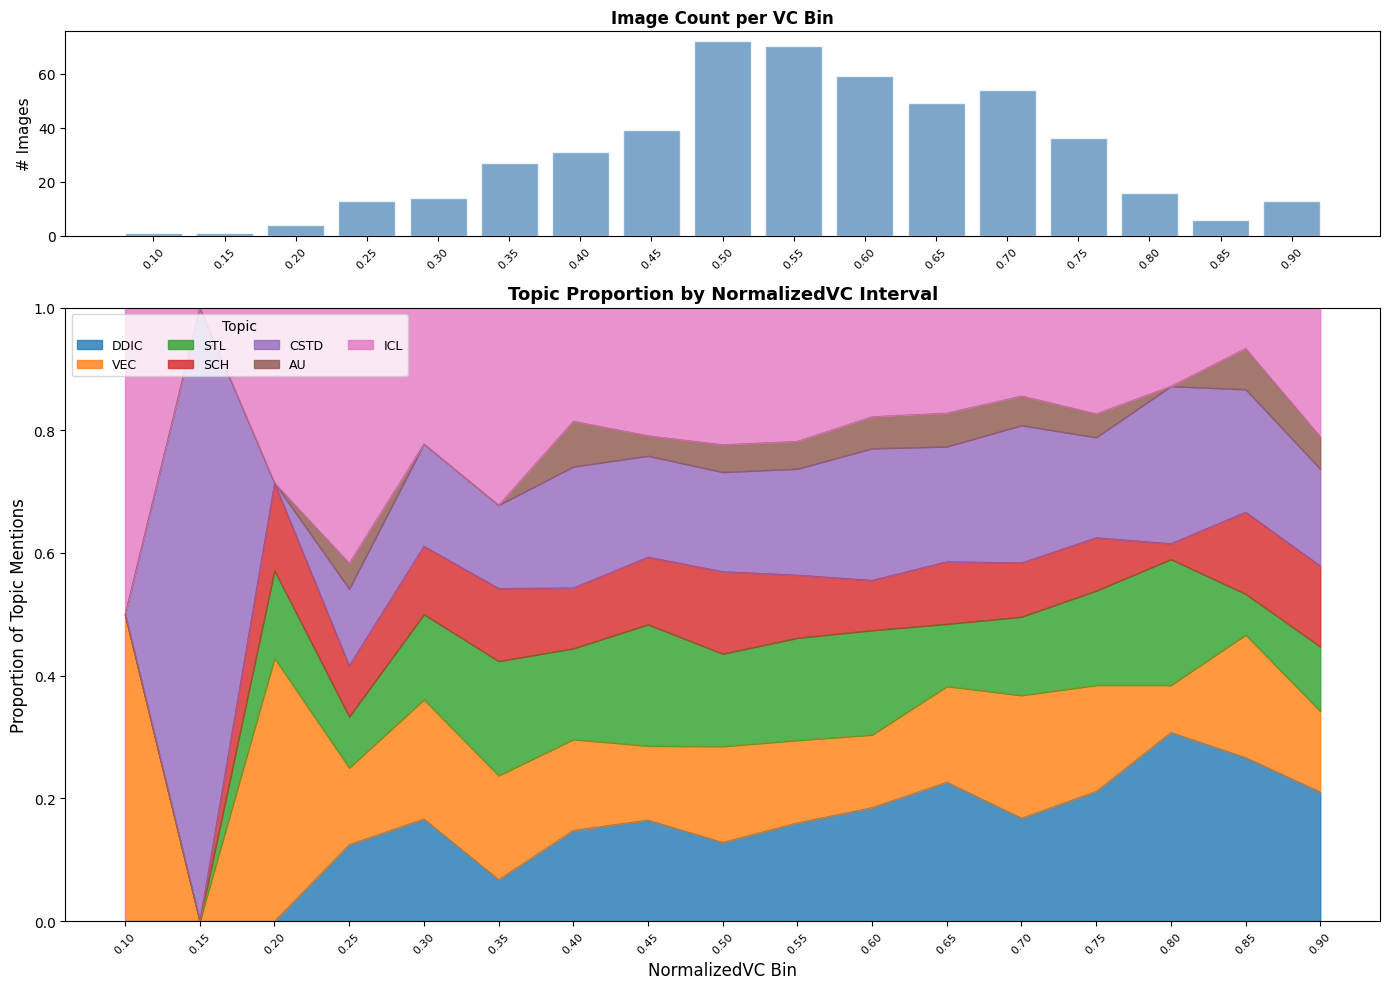

Saved: d:\Coding\Copilot\comment_post_processing\figures\topic_proportion_curves_by_vc_bin.png


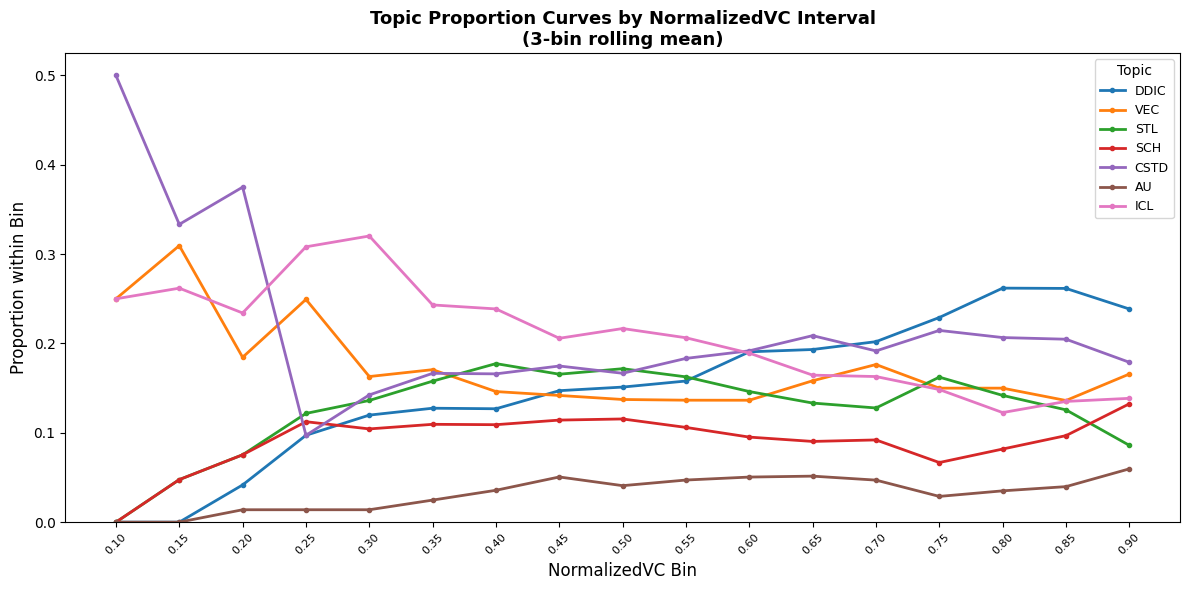

In [65]:
# ---- Topic proportion by NormalizedVC interval ----
# Bin VC scores, count topic mentions per bin, normalize to proportions

BIN_WIDTH = 0.05
vc_min, vc_max = df_images['NormalizedVC'].min(), df_images['NormalizedVC'].max()
bins = np.arange(np.floor(vc_min / BIN_WIDTH) * BIN_WIDTH,
                 np.ceil(vc_max / BIN_WIDTH) * BIN_WIDTH + BIN_WIDTH, BIN_WIDTH)
bin_labels = [f'{b:.2f}' for b in bins[:-1]]

df_images['vc_bin'] = pd.cut(df_images['NormalizedVC'], bins=bins, right=False, labels=bin_labels)

# Count images that mention each topic in each VC bin
topic_bin_counts = {}
for topic in topic_names:
    mask = df_images[topic].notna() & (df_images[topic].str.strip() != '')
    topic_bin_counts[topic] = df_images.loc[mask].groupby('vc_bin', observed=False).size()

df_topic_bins = pd.DataFrame(topic_bin_counts, index=bin_labels).fillna(0)

# Total mentions per bin (across all topics)
bin_totals = df_topic_bins.sum(axis=1)
# Proportion: each topic's share within a bin
df_topic_props = df_topic_bins.div(bin_totals, axis=0).fillna(0)

# Also get image count per bin for reference
img_per_bin = df_images.groupby('vc_bin', observed=False).size()

# --- Plot 1: Stacked area (proportions) ---
fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1, 3]})

# Top: image count per bin (context for where data is dense)
axes[0].bar(range(len(img_per_bin)), img_per_bin.values, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].set_ylabel('# Images', fontsize=11)
axes[0].set_title('Image Count per VC Bin', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(len(bin_labels)))
axes[0].set_xticklabels(bin_labels, rotation=45, fontsize=8)

# Bottom: stacked area of topic proportions
x = range(len(bin_labels))
bottoms = np.zeros(len(bin_labels))
for topic in topic_names:
    vals = df_topic_props[topic].values
    axes[1].fill_between(x, bottoms, bottoms + vals,
                         label=topic_abbrev[topic], color=topic_colors[topic], alpha=0.8)
    axes[1].plot(x, bottoms + vals, color=topic_colors[topic], linewidth=0.5, alpha=0.5)
    bottoms += vals

axes[1].set_ylabel('Proportion of Topic Mentions', fontsize=12)
axes[1].set_xlabel('NormalizedVC Bin', fontsize=12)
axes[1].set_title('Topic Proportion by NormalizedVC Interval', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(bin_labels, rotation=45, fontsize=8)
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=9, loc='upper left', ncol=4, title='Topic')

plt.tight_layout()
prop_path = os.path.join(fig_dir, 'topic_proportion_by_vc_bin.png')
fig.savefig(prop_path, dpi=150, bbox_inches='tight')
print(f'Saved: {prop_path}')
plt.show()

# --- Plot 2: Line curves of proportion per topic ---
fig, ax = plt.subplots(figsize=(12, 6))

for topic in topic_names:
    vals = df_topic_props[topic].values
    # Smooth slightly for readability (rolling mean, window=3)
    smoothed = pd.Series(vals).rolling(3, center=True, min_periods=1).mean().values
    ax.plot(x, smoothed, label=f'{topic_abbrev[topic]}',
            color=topic_colors[topic], linewidth=2, marker='o', markersize=3)

ax.set_xlabel('NormalizedVC Bin', fontsize=12)
ax.set_ylabel('Proportion within Bin', fontsize=12)
ax.set_title('Topic Proportion Curves by NormalizedVC Interval\n(3-bin rolling mean)', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(bin_labels, rotation=45, fontsize=8)
ax.legend(fontsize=9, title='Topic')
ax.set_ylim(0)

plt.tight_layout()
prop_line_path = os.path.join(fig_dir, 'topic_proportion_curves_by_vc_bin.png')
fig.savefig(prop_line_path, dpi=150, bbox_inches='tight')
print(f'Saved: {prop_line_path}')
plt.show()

# Clean up temp column
df_images.drop(columns=['vc_bin'], inplace=True)

In [66]:
# ---- Count unique keywords per topic (from per-image sheet) ----
print(f'{"Topic":<45s}  {"Images":>6s}  {"Total KWs":>9s}  {"Unique KWs":>10s}')
print('-' * 78)
for topic in topic_names:
    mask = df_images[topic].notna() & (df_images[topic].str.strip() != '')
    n_images = mask.sum()
    # Collect all keywords across images for this topic
    all_kws = []
    for val in df_images.loc[mask, topic]:
        for entry in str(val).split(';'):
            entry = re.sub(r'^\s*\([^)]*\)\s*', '', entry.strip()).strip()
            if entry:
                all_kws.append(entry)
    unique_kws = set(all_kws)
    print(f'{topic:<45s}  {n_images:>6d}  {len(all_kws):>9d}  {len(unique_kws):>10d}')
print('-' * 78)
# Total across all topics
all_total = []
all_unique = set()
for topic in topic_names:
    mask = df_images[topic].notna() & (df_images[topic].str.strip() != '')
    for val in df_images.loc[mask, topic]:
        for entry in str(val).split(';'):
            entry = re.sub(r'^\s*\([^)]*\)\s*', '', entry.strip()).strip()
            if entry:
                all_total.append(entry)
                all_unique.add(entry)
print(f'{"TOTAL":<45s}  {"":>6s}  {len(all_total):>9d}  {len(all_unique):>10d}')

Topic                                          Images  Total KWs  Unique KWs
------------------------------------------------------------------------------
Data Density / Image Clutter                      209        330          41
Visual Encoding Clarity                           186        284         131
Semantics / Text Legibility                       183        308          90
Schema                                            124        159          12
Color, Symbol, and Texture Details                222        303          72
Aesthetics Uncertainty                             52         58          14
Immediacy / Cognitive Load                        244        345          51
------------------------------------------------------------------------------
TOTAL                                                       1787         409


In [54]:
# ---- Build reverse mapping: any original keyword → shortlist representative ----
# Uses the merge_map from Step 1 (manual groups + TF-IDF) to trace back to final keywords.

final_keywords = set(df_shortlist['keyword'].tolist())

# Build mapping: original keyword → shortlist representative (if any)
orig_to_final = {}

# Direct matches
for kw in final_keywords:
    orig_to_final[kw] = kw

# Use merge_map: if a keyword was merged into a representative, and that representative
# (or its own merge target) is in the final shortlist, map the original keyword there.
for kw, rep in merge_map.items():
    # The rep might itself have been merged further (chain resolution)
    final_rep = rep
    while final_rep in merge_map and merge_map[final_rep] != final_rep:
        final_rep = merge_map[final_rep]
    if final_rep in final_keywords:
        orig_to_final[kw] = final_rep

print(f'Final shortlist: {len(final_keywords)} keywords')
print(f'Total original keywords that map to a final keyword: {len(orig_to_final)}')

# ---- Parse topic columns and match ----
def extract_keywords_from_cell(cell_value):
    """Parse a topic cell like '(+) keyword1; (-) keyword2' into raw keywords."""
    if pd.isna(cell_value) or not str(cell_value).strip():
        return []
    keywords = []
    for entry in str(cell_value).split(';'):
        entry = entry.strip()
        # Strip sentiment prefix: (+), (-), (+/-), etc.
        entry = re.sub(r'^\s*\([^)]*\)\s*', '', entry).strip()
        if entry:
            keywords.append(entry)
    return keywords

# For each image row, collect all original keywords across 7 topic columns,
# then find which ones match a final keyword (via direct or merge mapping)
matched_col = []
for _, row in df_images.iterrows():
    all_orig_kws = []
    for topic_col in topic_names:
        all_orig_kws.extend(extract_keywords_from_cell(row.get(topic_col)))

    # Map to final keywords (deduplicate, preserve order)
    seen = set()
    matched = []
    for kw in all_orig_kws:
        final_kw = orig_to_final.get(kw)
        if final_kw and final_kw not in seen:
            matched.append(final_kw)
            seen.add(final_kw)

    matched_col.append('; '.join(matched))

df_images['final_keywords'] = matched_col

# ---- Summary ----
n_with_match = (df_images['final_keywords'] != '').sum()
avg_matches = df_images['final_keywords'].apply(lambda x: len(x.split('; ')) if x else 0).mean()
print(f'\nImages with >=1 matched keyword: {n_with_match} / {len(df_images)}')
print(f'Average matched keywords per image: {avg_matches:.1f}')
print(f'\nSample rows:')
print(df_images[['ImageName', 'VisType', 'final_keywords']].head(10).to_string(index=False))


Final shortlist: 41 keywords
Total original keywords that map to a final keyword: 384

Images with >=1 matched keyword: 502 / 505
Average matched keywords per image: 2.9

Sample rows:
                   ImageName   VisType                                                                                           final_keywords
             VisJ.1431.7.png      Line                                                                                unclear meaning/confusing
         InfoVisJ.2412.7.png schematic                                                                                                  symbols
           SciVisJ.995.5.png       Bar      domain-specific concepts (e.g., chemical, biology, map); title/axis/label; take longer to interpret
              VisC.503.6.png       Bar               domain-specific concepts (e.g., chemical, biology, map); easy to interpret/read/understand
              VisC.373.3.png schematic                                                          

In [55]:
# ---- Quick verification ----
n_with = (df_images['final_keywords'] != '').sum()
n_total = len(df_images)
avg_kw = df_images['final_keywords'].apply(lambda x: len(x.split('; ')) if x else 0).mean()
print(f'Images with matched keywords: {n_with}/{n_total}')
print(f'Average keywords per image: {avg_kw:.1f}')
print(f'\nFirst 5 rows:')
for _, r in df_images[['ImageName', 'final_keywords']].head(5).iterrows():
    print(f'  {r["ImageName"]}: {r["final_keywords"][:100]}{"..." if len(r["final_keywords"]) > 100 else ""}')

Images with matched keywords: 502/505
Average keywords per image: 2.9

First 5 rows:
  VisJ.1431.7.png: unclear meaning/confusing
  InfoVisJ.2412.7.png: symbols
  SciVisJ.995.5.png: domain-specific concepts (e.g., chemical, biology, map); title/axis/label; take longer to interpret
  VisC.503.6.png: domain-specific concepts (e.g., chemical, biology, map); easy to interpret/read/understand
  VisC.373.3.png: 


In [56]:
# ---- Save only ImageName, VisType, final_keywords ----
out_path = os.path.join(fig_dir, 'images_with_final_keywords.csv')
df_images[['ImageName', 'VisType', 'final_keywords']].to_csv(out_path, index=False)
print(f'Saved to: {out_path}')
print(f'Shape: {df_images[["ImageName", "VisType", "final_keywords"]].shape}')
df_images[['ImageName', 'VisType', 'final_keywords']].head(10)

Saved to: d:\Coding\Copilot\comment_post_processing\figures\images_with_final_keywords.csv
Shape: (505, 3)


,ImageName,VisType,final_keywords
0,VisJ.1431.7.png,Line,unclear meaning/confusing
1,InfoVisJ.2412.7.png,schematic,symbols
2,SciVisJ.995.5.png,Bar,"domain-specific concepts (e.g., chemical, biol..."
3,VisC.503.6.png,Bar,"domain-specific concepts (e.g., chemical, biol..."
4,VisC.373.3.png,schematic,
5,InfoVisJ.541.22.png,schematic,simple visual elements
6,VisC.199.5.png,Line,easy to interpret/read/understand
7,VASTC.72.13.png,Bar,much/more data/info/info spread; color variety...
8,economist_daily_chart_75.png,Bar,more charts/points/lines/shapes/elements; line...
9,whoJ40_2.png,Area,color variety/arrangement/distribution; distra...


In [57]:
# ---- Save orig_to_final keyword mapping for reuse ----
df_mapping = pd.DataFrame(list(orig_to_final.items()), columns=['original_keyword', 'final_keyword'])
mapping_path = os.path.join(fig_dir, 'keyword_synonym_mapping.csv')
df_mapping.to_csv(mapping_path, index=False)
print(f'Saved keyword mapping ({len(df_mapping)} entries) to: {mapping_path}')

Saved keyword mapping (384 entries) to: d:\Coding\Copilot\comment_post_processing\figures\keyword_synonym_mapping.csv


## Step 8: Map Final Keywords to HumanCuration Sheet

Load sheet `1166121277` which contains `{topic}_ (HumanCuration)` columns.
For each topic column, produce a paired `{topic}_ (FinalKeyword)` column
containing whichever of the 40 shortlisted keywords the original keyword maps to.


In [39]:
# ---- Load HumanCuration sheet ----
human_sheet_id = '1166121277'
df_human = pd.read_csv(
    f'https://docs.google.com/spreadsheets/d/{spreadsheet_id}/export?gid={human_sheet_id}&format=csv'
)
print(f'HumanCuration sheet: {df_human.shape[0]} rows × {df_human.shape[1]} columns')
print(f'Columns: {list(df_human.columns)}')


HumanCuration sheet: 318 rows × 36 columns
Columns: ['Immediacy / Cognitive Load_count', 'Immediacy / Cognitive Load', 'Immediacy / Cognitive Load (AIcurated)', 'Immediacy / Cognitive Load_sentiment', 'Immediacy / Cognitive Load (HumanCuration)', 'ICLToChangeTo', 'Data Density / Image Clutter_sentiment', 'Data Density / Image Clutter_count', 'Data Density / Image Clutter', 'Data Density / Image Clutter (AIcurated)', 'Data Density / Image Clutter (HumanCuration)', 'Color, Symbol, and Texture Details_sentiment', 'Color, Symbol, and Texture Details_count', 'Color, Symbol, and Texture Details', 'Color, Symbol, and Texture Details (AIcurated)', 'Color, Symbol, and Texture Details (HumanCuration)', 'Semantics / Text Legibility_sentiment', 'Semantics / Text Legibility_count', 'Semantics / Text Legibility', 'Semantics / Text Legibility (AIcurated)', 'Semantics / Text Legibility (HumanCuration)', 'Visual Encoding Clarity_sentiment', 'Visual Encoding Clarity_count', 'Visual Encoding Clarity', 'V

In [71]:
# ---- Map HumanCuration keywords → final 41 shortlist keywords ----
# For each topic, parse the "(HumanCuration)" column and find any matching final keyword.
# Output: all HumanCuration columns first, then all (BeauVis) columns on the right.

# orig_to_final is built in Step 7 (maps any original keyword → shortlist representative)

# ---- Extra mappings for HumanCuration-only labels. ----
# These fall into two categories:
#   (A) NOT_IN_DATASET: curated labels that were renamed/reformatted and are not in the original df_all
#   (B) NOT_SHORTLIST: keywords that survived Step 1b but scored below the top-41 cutoff,
#       mapped here to their closest shortlisted representative.
extra_map = {
    # --- VEC ---
    # (A) curated-only labels
    'scattered shapes (e.g., dots, squares, pictures)': 'more charts/points/lines/shapes/elements',
    'clear colors/shapes':                              'visual clarity/appealing',
    'ordered set':                                      'ordered',
    'abstract shapes or colors':                        'domain-specific concepts (e.g., chemical, biology, map)',
    # (B) not-shortlisted VEC keywords → closest shortlisted representative
    'less organized elements':      'distracting/confusing/unclear',
    'shape increase/decrease point':'shape variation',
    'shape point of interest':      'shape position',
    'shape size':                   'shape variation',

    # --- STL ---
    # (A) curated-only labels
    'title/axis/label/descriptions': 'title/axis/label',
    # (B) not-shortlisted STL keywords → closest shortlisted representative
    'little/less text/numbers/context': 'amount of words/context/numbers',
    'clear text arrangement/density':   'word rotation/small font size',

    # --- CSTD ---
    # (A) curated-only labels
    'unclear colormaps':                                    'color shading',
    'distinguishable color variety/arrangement/distribution':'color variety/arrangement/distribution',
    'distinguishable/full/highly contrast color uses':       'color variety/arrangement/distribution',
    'distinguishable/full color uses':                       'color variety/arrangement/distribution',
    'clear color uses':                                      'color variety/arrangement/distribution',
    'readable/distinguishable colors':                       'color variety/arrangement/distribution',
    'clear colored bars/charts':                             'color variety/arrangement/distribution',
    'no color':                                              'color variety/arrangement/distribution',
    # (B) not-shortlisted CSTD keywords → closest shortlisted representative
    'two colors':           'color variety/arrangement/distribution',
    'bright colors':        'color variety/arrangement/distribution',
    'monochrome':           'color shading',
    'blurry colors/images': 'unclear coloring',
}

# Validate every extra_map target is actually in the shortlist
invalid = {k: v for k, v in extra_map.items() if v not in final_keywords}
if invalid:
    print(f'WARNING: extra_map targets not in shortlist: {invalid}')
else:
    print(f'All {len(extra_map)} extra_map targets validated against shortlist.')

# Extend orig_to_final with extra_map (only add; do not overwrite existing entries)
n_added = 0
for kw, target in extra_map.items():
    if kw not in orig_to_final:
        orig_to_final[kw] = target
        n_added += 1
print(f'Added {n_added} new entries to orig_to_final (total: {len(orig_to_final)})')

# ---- Run the mapping ----
# Build two lists of columns: HumanCuration cols first, then BeauVis cols on the right
human_frames = []
beauvis_series = {}

for topic in topic_names:
    human_col  = f'{topic} (HumanCuration)'
    beauvis_col = f'{topic} (BeauVis)'

    if human_col not in df_human.columns:
        print(f'WARNING: column not found: {human_col}')
        continue

    human_frames.append(df_human[[human_col]].copy())

    final_kws = []
    for cell_val in df_human[human_col]:
        kws = extract_keywords_from_cell(cell_val)
        seen = set()
        matched = []
        for kw in kws:
            fk = orig_to_final.get(kw)
            if fk and fk not in seen:
                matched.append(fk)
                seen.add(fk)
        final_kws.append('; '.join(matched))

    beauvis_series[beauvis_col] = final_kws

# Concatenate: all HumanCuration cols, then all BeauVis cols
df_human_cols = pd.concat(human_frames, axis=1)
df_beauvis_cols = pd.DataFrame(beauvis_series)
df_output = pd.concat([df_human_cols, df_beauvis_cols], axis=1)

# Save
out_human_path = os.path.join(fig_dir, 'humancuration_with_final_keywords.csv')
df_output.to_csv(out_human_path, index=False)
print(f'Saved: {out_human_path}')
print(f'Shape: {df_output.shape}  ({len(human_frames)} HumanCuration + {len(beauvis_series)} BeauVis columns)')

# Coverage summary
print(f'\n--- Match rate per topic ---')
total_matched = total_has_kw = 0
for topic in topic_names:
    beauvis_col = f'{topic} (BeauVis)'
    human_col   = f'{topic} (HumanCuration)'
    if beauvis_col not in df_output.columns:
        continue
    n_matched = (df_output[beauvis_col] != '').sum()
    n_has_kw  = (df_output[human_col].notna() & (df_output[human_col].str.strip() != '')).sum()
    total_matched += n_matched
    total_has_kw  += n_has_kw
    pct = 100 * n_matched / n_has_kw if n_has_kw else 0
    print(f'  {topic_abbrev[topic]:4s}: {n_matched:3d}/{n_has_kw:3d}  ({pct:.1f}%)')
print(f'\n  OVERALL: {total_matched}/{total_has_kw}  ({100*total_matched/total_has_kw:.1f}%)')

df_output


All 23 extra_map targets validated against shortlist.
Added 0 new entries to orig_to_final (total: 407)
Saved: d:\Coding\Copilot\comment_post_processing\figures\humancuration_with_final_keywords.csv
Shape: (318, 14)  (7 HumanCuration + 7 BeauVis columns)

--- Match rate per topic ---
  DDIC: 314/314  (100.0%)
  VEC : 254/264  (96.2%)
  STL : 286/291  (98.3%)
  SCH : 167/168  (99.4%)
  CSTD: 259/259  (100.0%)
  AU  :  59/ 59  (100.0%)
  ICL : 312/318  (98.1%)

  OVERALL: 1651/1673  (98.7%)


,Data Density / Image Clutter (HumanCuration),Visual Encoding Clarity (HumanCuration),Semantics / Text Legibility (HumanCuration),Schema (HumanCuration),"Color, Symbol, and Texture Details (HumanCuration)",Aesthetics Uncertainty (HumanCuration),Immediacy / Cognitive Load (HumanCuration),Data Density / Image Clutter (BeauVis),Visual Encoding Clarity (BeauVis),Semantics / Text Legibility (BeauVis),Schema (BeauVis),"Color, Symbol, and Texture Details (BeauVis)",Aesthetics Uncertainty (BeauVis),Immediacy / Cognitive Load (BeauVis)
0,clustered data/info,2D/3D,with legend,2D/3D,ambiguous/confusing colors,visual clarity/appealing,attention/squinting to understand,little data/info,2D/3D,too much legend,2D/3D,lack of color contrast / hard to distinguish c...,visual clarity/appealing,take longer to interpret
1,concentrated,2D/3D,almost no explanation,abstract shapes or colors,ambiguous/confusing colors,arbitrary imaging,attention/squinting to understand,overlapping shapes/colors/lines,2D/3D,title/axis/label,"domain-specific concepts (e.g., chemical, biol...",lack of color contrast / hard to distinguish c...,"domain-specific concepts (e.g., chemical, biol...",take longer to interpret
2,data intersection,2D/3D,ambiguous numbers,abstract shapes or colors,ambiguous/confusing colors,unclear colors/contrast,attention/squinting to understand,2D/3D,2D/3D,amount of words/context/numbers,"domain-specific concepts (e.g., chemical, biol...",lack of color contrast / hard to distinguish c...,unclear colors/contrast,take longer to interpret
3,dense points/lines/shapes/elements,2D/3D,too many subjects,abstract shapes or colors,ambiguous/confusing colors,unclear colors/contrast,complicated to process,more charts/points/lines/shapes/elements,2D/3D,more charts/points/lines/shapes/elements,"domain-specific concepts (e.g., chemical, biol...",lack of color contrast / hard to distinguish c...,unclear colors/contrast,hard to interpret/read/understand
4,dense points/lines/shapes/elements,2D/3D,axis meaning,"a specific technique, e.g., bar, pie, circle",ambiguous/confusing colors,unclear colors/contrast,complicated to process,more charts/points/lines/shapes/elements,2D/3D,title/axis/label,"domain-specific concepts (e.g., chemical, biol...",lack of color contrast / hard to distinguish c...,unclear colors/contrast,hard to interpret/read/understand
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
313,more parameters/variables,NaN,NaN,NaN,NaN,NaN,unclear meaning/confusing,more parameters/variables,,,,,,unclear meaning/confusing
314,NaN,NaN,NaN,NaN,NaN,NaN,unclear meaning/confusing,,,,,,,unclear meaning/confusing
315,NaN,NaN,NaN,NaN,NaN,NaN,unclear meaning/confusing,,,,,,,unclear meaning/confusing
316,NaN,NaN,NaN,NaN,NaN,NaN,unclear meaning/confusing,,,,,,,unclear meaning/confusing
